# Continuous Passing-Lane Analysis

This notebook extends the single-frame passing-lane analysis by calculating
potential passing lanes continuously throughout controlled possession.

For every frame with an identified ball carrier:

1. identify all available teammates,
2. construct a potential passing lane to each teammate,
3. measure the closest defender's distance to the lane,
4. record where along the lane that defender is positioned.

This produces a frame-level dataset that can later be used to identify
defenders actively closing passing lanes.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch
from matplotlib.lines import Line2D
from matplotlib.animation import FuncAnimation, PillowWriter

DATA_DIR = Path("../data")

home_path = DATA_DIR / "Sample_Game_1_RawTrackingData_Home_Team.csv"
away_path = DATA_DIR / "Sample_Game_1_RawTrackingData_Away_Team.csv"
events_path = DATA_DIR / "Sample_Game_1_RawEventsData.csv"

home = pd.read_csv(home_path, skiprows=2)
away = pd.read_csv(away_path, skiprows=2)
events = pd.read_csv(events_path)

## Clean Data

In [21]:
def clean_tracking_columns(df):
    df = df.copy()
    cols = list(df.columns)

    for i in range(3, len(cols), 2):
        name = cols[i]
        cols[i] = f"{name}_x"
        cols[i + 1] = f"{name}_y"

    df.columns = cols
    return df


home = clean_tracking_columns(home)
away = clean_tracking_columns(away)

In [22]:
PITCH_LENGTH = 105
PITCH_WIDTH = 68

def convert_tracking_to_metres(df):
    df = df.copy()

    x_cols = [c for c in df.columns if c.endswith("_x")]
    y_cols = [c for c in df.columns if c.endswith("_y")]

    df[x_cols] = df[x_cols] * PITCH_LENGTH
    df[y_cols] = (1 - df[y_cols]) * PITCH_WIDTH

    return df


home = convert_tracking_to_metres(home)
away = convert_tracking_to_metres(away)

home_x_cols = [
    c for c in home.columns
    if c.endswith("_x") and c != "Ball_x"
]

away_x_cols = [
    c for c in away.columns
    if c.endswith("_x") and c != "Ball_x"
]

## Possession detector from notebook 3

In [25]:
possession = pd.read_csv(
    "../data/processed/possession.csv"
)

possession.head()

,frame,time,period,possession_team,ball_carrier,distance_to_ball
0,1,0.04,1.0,Away,Player19,0.000000
1,2,0.08,1.0,NaN,NaN,3.685200
2,3,0.12,1.0,Home,Player10,1.675053
3,4,0.16,1.0,Home,Player10,0.744770
4,5,0.20,1.0,Home,Player10,1.892089


## Helper functions

In [26]:
def active_players(frame, x_cols):

    players = []

    for x_col in x_cols:

        player = x_col.replace("_x", "")
        y_col = x_col.replace("_x", "_y")

        x = frame[x_col]
        y = frame[y_col]

        if pd.notna(x) and pd.notna(y):
            players.append((player, x, y))

    return players

In [27]:
home_by_frame = home.set_index("Frame")
away_by_frame = away.set_index("Frame")

In [29]:
def point_to_segment_metrics(point, start, end):

    point = np.array(point, dtype=float)
    start = np.array(start, dtype=float)
    end = np.array(end, dtype=float)

    segment = end - start
    length_sq = np.dot(segment, segment)

    if length_sq == 0:
        return np.linalg.norm(point - start), 0

    t = np.dot(point - start, segment) / length_sq

    t_clipped = np.clip(t, 0, 1)

    closest_point = start + t_clipped * segment

    distance = np.linalg.norm(
        point - closest_point
    )

    return distance, t

All passing lanes for one possession frame.

In [38]:
def passing_lanes_for_frame(
    frame_id,
    possession_by_frame,
    home_by_frame,
    away_by_frame,
    home_x_cols,
    away_x_cols
):
    # Get possession information
    if frame_id not in possession_by_frame.index:
        return pd.DataFrame()

    poss_row = possession_by_frame.loc[frame_id]

    team = poss_row["possession_team"]
    passer = poss_row["ball_carrier"]

    # Skip frames without controlled possession
    if pd.isna(team) or pd.isna(passer):
        return pd.DataFrame()

    home_frame = home_by_frame.loc[frame_id]
    away_frame = away_by_frame.loc[frame_id]

    # Assign attacking and defending teams
    if team == "Home":
        attacking_frame = home_frame
        defending_frame = away_frame
        attacking_x_cols = home_x_cols
        defending_x_cols = away_x_cols
    else:
        attacking_frame = away_frame
        defending_frame = home_frame
        attacking_x_cols = away_x_cols
        defending_x_cols = home_x_cols

    attackers = active_players(
        attacking_frame,
        attacking_x_cols
    )

    defenders = active_players(
        defending_frame,
        defending_x_cols
    )

    # Locate passer
    passer_info = [
        p for p in attackers
        if p[0] == passer
    ]

    if not passer_info:
        return pd.DataFrame()

    _, passer_x, passer_y = passer_info[0]
    passer_xy = (passer_x, passer_y)

    # Everyone except the ball carrier is a potential receiver
    receivers = [
        p for p in attackers
        if p[0] != passer
    ]

    results = []

    for receiver, rx, ry in receivers:

        receiver_xy = (rx, ry)

        pass_length = np.linalg.norm(
            np.array(receiver_xy) -
            np.array(passer_xy)
        )

        valid_defenders = []

        for defender, dx, dy in defenders:

            distance, t = point_to_segment_metrics(
                point=(dx, dy),
                start=passer_xy,
                end=receiver_xy
            )

            # Defender must project between passer and receiver
            if 0 < t < 1:
                valid_defenders.append(
                    (defender, distance, t)
                )

        if valid_defenders:

            closest_defender, lane_clearance, position = min(
                valid_defenders,
                key=lambda x: x[1]
            )

        else:
            closest_defender = None
            lane_clearance = np.nan
            position = np.nan

        results.append({
            "frame": frame_id,
            "time": poss_row["time"],
            "team": team,
            "passer": passer,
            "receiver": receiver,
            "passer_x": passer_x,
            "passer_y": passer_y,
            "receiver_x": rx,
            "receiver_y": ry,
            "pass_length": pass_length,
            "closest_defender": closest_defender,
            "lane_clearance": lane_clearance,
            "position_along_lane": position
        })

    return pd.DataFrame(results)

Test with a known frame.

In [32]:
test_lanes = passing_lanes_for_frame(
    frame_id=7519,
    possession=possession,
    home_by_frame=home_by_frame,
    away_by_frame=away_by_frame,
    home_x_cols=home_x_cols,
    away_x_cols=away_x_cols
)

test_lanes.sort_values("lane_clearance")

,frame,time,team,passer,receiver,passer_x,passer_y,receiver_x,receiver_y,pass_length,closest_defender,lane_clearance,position_along_lane
8,7519,300.76,Away,Player19,Player23,27.81765,48.52344,20.52225,41.70644,9.984706,Player6,0.044272,0.801639
9,7519,300.76,Away,Player19,Player24,27.81765,48.52344,12.97170,47.02472,14.921407,Player7,0.308966,0.539956
6,7519,300.76,Away,Player19,Player21,27.81765,48.52344,20.30385,58.36848,12.384749,Player8,0.418717,0.339855
7,7519,300.76,Away,Player19,Player22,27.81765,48.52344,21.02835,15.16196,34.045307,Player5,0.632337,0.672111
3,7519,300.76,Away,Player19,Player17,27.81765,48.52344,39.48630,32.40472,19.899008,Player9,1.435282,0.548570
4,7519,300.76,Away,Player19,Player18,27.81765,48.52344,28.73010,62.96664,14.471993,Player8,2.443304,0.238581
1,7519,300.76,Away,Player19,Player15,27.81765,48.52344,40.97205,55.87764,15.070584,Player10,3.222073,0.796660
2,7519,300.76,Away,Player19,Player16,27.81765,48.52344,50.18685,45.83064,22.530696,Player10,4.464970,0.514916
0,7519,300.76,Away,Player19,Player25,27.81765,48.52344,81.30990,34.84592,55.213181,Player10,5.936968,0.197808
5,7519,300.76,Away,Player19,Player20,27.81765,48.52344,34.53765,40.67148,10.334973,Player6,7.994577,0.038066


In [33]:
test_lanes[
    ["passer", "receiver",
     "pass_length",
     "closest_defender",
     "lane_clearance",
     "position_along_lane"]
]

,passer,receiver,pass_length,closest_defender,lane_clearance,position_along_lane
0,Player19,Player25,55.213181,Player10,5.936968,0.197808
1,Player19,Player15,15.070584,Player10,3.222073,0.796660
2,Player19,Player16,22.530696,Player10,4.464970,0.514916
3,Player19,Player17,19.899008,Player9,1.435282,0.548570
4,Player19,Player18,14.471993,Player8,2.443304,0.238581
5,Player19,Player20,10.334973,Player6,7.994577,0.038066
6,Player19,Player21,12.384749,Player8,0.418717,0.339855
7,Player19,Player22,34.045307,Player5,0.632337,0.672111
8,Player19,Player23,9.984706,Player6,0.044272,0.801639
9,Player19,Player24,14.921407,Player7,0.308966,0.539956


Check visualization.

In [ ]:
def lane_color(clearance):
    if pd.isna(clearance):
        return "gray"
    elif clearance < 1:
        return "red"
    elif clearance < 2.5:
        return "orange"
    else:
        return "green"

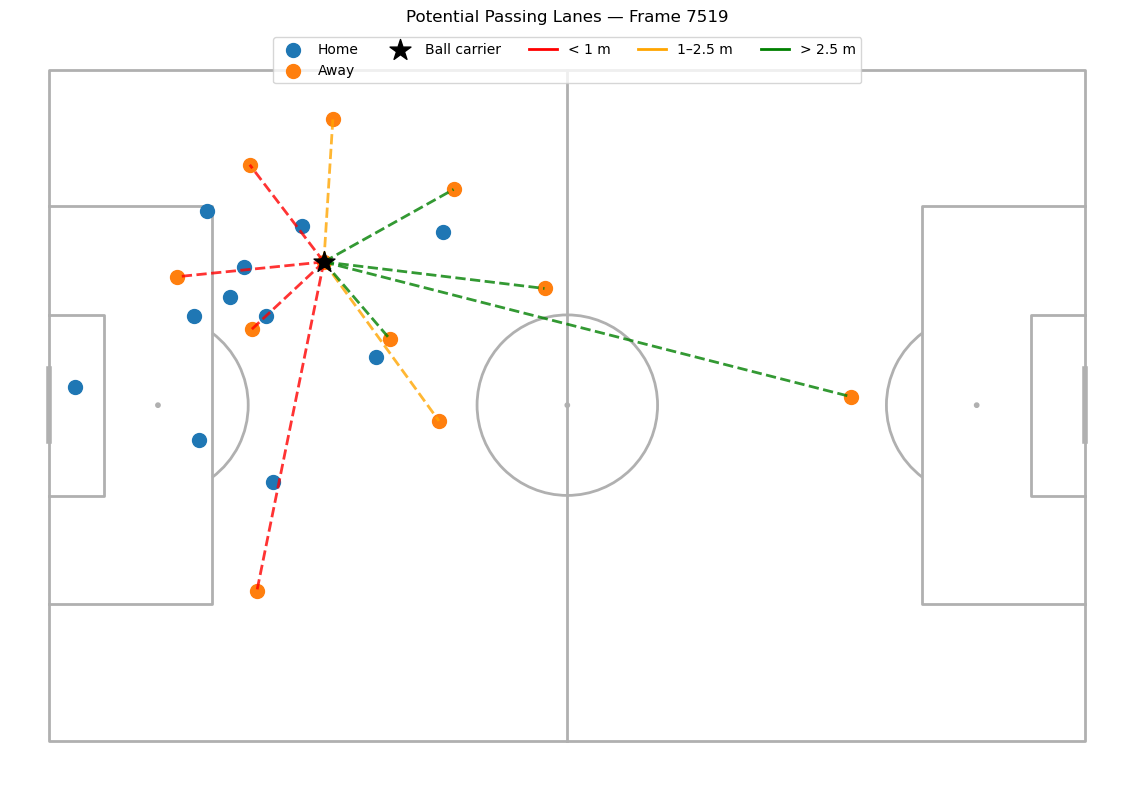

In [35]:
frame_id = 7519

home_frame = home_by_frame.loc[frame_id]
away_frame = away_by_frame.loc[frame_id]

home_players = active_players(home_frame, home_x_cols)
away_players = active_players(away_frame, away_x_cols)

pitch = Pitch(
    pitch_type="custom",
    pitch_length=105,
    pitch_width=68
)

fig, ax = pitch.draw(figsize=(12, 8))

# Players
ax.scatter(
    [p[1] for p in home_players],
    [p[2] for p in home_players],
    s=100,
    label="Home"
)

ax.scatter(
    [p[1] for p in away_players],
    [p[2] for p in away_players],
    s=100,
    label="Away"
)

# Passing lanes
for _, row in test_lanes.iterrows():

    ax.plot(
        [row["passer_x"], row["receiver_x"]],
        [row["passer_y"], row["receiver_y"]],
        linestyle="--",
        linewidth=2,
        color=lane_color(row["lane_clearance"]),
        alpha=0.8
    )

# Highlight carrier
carrier = test_lanes.iloc[0]

ax.scatter(
    carrier["passer_x"],
    carrier["passer_y"],
    s=250,
    marker="*",
    color="black",
    label="Ball carrier",
    zorder=5
)

# Ball
ax.scatter(
    home_frame["Ball_x"],
    home_frame["Ball_y"],
    s=50,
    color="black",
    zorder=6
)

clearance_legend = [
    Line2D([0], [0], color="red", lw=2, label="< 1 m"),
    Line2D([0], [0], color="orange", lw=2, label="1–2.5 m"),
    Line2D([0], [0], color="green", lw=2, label="> 2.5 m")
]

handles, labels = ax.get_legend_handles_labels()
handles.extend(clearance_legend)

ax.legend(handles=handles, loc="upper center", ncol=5)

ax.set_title(
    f"Potential Passing Lanes — Frame {frame_id}"
)

plt.show()

Looks good (identical to the one in notebook 3).

Now scale it up to the whole match. For this index our possession data by frames.

In [36]:
possession_by_frame = possession.set_index("frame")

We only care about controlled possession frames.

In [39]:
controlled_frames = possession.loc[
    possession["ball_carrier"].notna(),
    "frame"
].astype(int).tolist()

len(controlled_frames)

115102

In [40]:
all_lane_results = []

for i, frame_id in enumerate(controlled_frames):

    frame_lanes = passing_lanes_for_frame(
        frame_id=frame_id,
        possession_by_frame=possession_by_frame,
        home_by_frame=home_by_frame,
        away_by_frame=away_by_frame,
        home_x_cols=home_x_cols,
        away_x_cols=away_x_cols
    )

    if not frame_lanes.empty:
        all_lane_results.append(frame_lanes)

    if (i + 1) % 10000 == 0:
        print(
            f"Processed {i + 1:,} / "
            f"{len(controlled_frames):,} frames"
        )

Processed 10,000 / 115,102 frames
Processed 20,000 / 115,102 frames
Processed 30,000 / 115,102 frames
Processed 40,000 / 115,102 frames
Processed 50,000 / 115,102 frames
Processed 60,000 / 115,102 frames
Processed 70,000 / 115,102 frames
Processed 80,000 / 115,102 frames
Processed 90,000 / 115,102 frames
Processed 100,000 / 115,102 frames
Processed 110,000 / 115,102 frames


In [41]:
continuous_lanes = pd.concat(
    all_lane_results,
    ignore_index=True
)

continuous_lanes.shape

(1151024, 13)

In [42]:
continuous_lanes.head()

,frame,time,team,passer,receiver,passer_x,passer_y,receiver_x,receiver_y,pass_length,closest_defender,lane_clearance,position_along_lane
0,1,0.04,Away,Player19,Player25,47.7456,41.67788,95.03445,35.72584,47.661957,Player9,1.439213,0.156623
1,1,0.04,Away,Player19,Player15,47.7456,41.67788,61.31265,53.86008,18.233783,Player9,4.699615,0.327734
2,1,0.04,Away,Player19,Player16,47.7456,41.67788,71.04090,36.23720,23.922207,Player10,0.686188,0.447112
3,1,0.04,Away,Player19,Player17,47.7456,41.67788,70.67550,15.99632,34.428518,Player10,5.587816,0.265652
4,1,0.04,Away,Player19,Player18,47.7456,41.67788,42.82215,26.16300,16.277342,Player6,1.898386,0.437343


In [43]:
continuous_lanes[
    [
        "pass_length",
        "lane_clearance",
        "position_along_lane"
    ]
].describe()

,pass_length,lane_clearance,position_along_lane
count,1.151024e+06,1.056294e+06,1.056294e+06
mean,3.623437e+01,4.790493e+00,5.975149e-01
std,1.925646e+01,5.775005e+00,3.005602e-01
min,3.885595e-02,3.610262e-07,3.554552e-08
25%,2.123284e+01,1.105810e+00,3.525364e-01
50%,3.426709e+01,2.724327e+00,6.650300e-01
75%,4.857814e+01,6.128094e+00,8.589710e-01
max,1.094638e+02,8.564809e+01,9.999999e-01


In [44]:
continuous_lanes.groupby("frame").size().describe()

count    115102.000000
mean         10.000035
std           0.005895
min          10.000000
25%          10.000000
50%          10.000000
75%          10.000000
max          11.000000
dtype: float64

After some sanity check we can save the passing lanes as we don't want to generate this again.

In [45]:
continuous_lanes.to_csv(
    "../data/processed/continuous_passing_lanes.csv",
    index=False
)

Investigate frames with 11 passing lanes (should be only 10 passing options per frame).

In [46]:
lane_counts = continuous_lanes.groupby("frame").size()

weird_frames = lane_counts[lane_counts != 10]

weird_frames

frame
46706     11
110849    11
119381    11
121392    11
dtype: int64

Get rid of these.

In [47]:
valid_frames = lane_counts[lane_counts == 10].index

continuous_lanes = continuous_lanes[
    continuous_lanes["frame"].isin(valid_frames)
].copy()

Next, we want to look at how passing lanes change over time. That is how the defenders move to close or open the gaps.

In [48]:
continuous_lanes = continuous_lanes.sort_values(
    ["team", "passer", "receiver", "frame"]
)

continuous_lanes["frame_gap"] = (
    continuous_lanes
    .groupby(["team", "passer", "receiver"])["frame"]
    .diff()
)

continuous_lanes["clearance_change"] = (
    continuous_lanes
    .groupby(["team", "passer", "receiver"])["lane_clearance"]
    .diff()
)

We care about only continuous frames that is when we have the same ball carrier.

In [49]:
continuous_lanes.loc[
    continuous_lanes["frame_gap"] != 1,
    "clearance_change"
] = np.nan

Tracking is 25 Hz and we want to convert to meters per second.

In [50]:
continuous_lanes["clearance_change_per_second"] = (
    continuous_lanes["clearance_change"] * 25
)

We also want to make sure to not calculate this closing-lane motion if the closest defender changes within the continuous frames.

In [51]:
continuous_lanes["previous_closest_defender"] = (
    continuous_lanes
    .groupby(["team", "passer", "receiver"])["closest_defender"]
    .shift()
)

continuous_lanes["same_defender"] = (
    continuous_lanes["closest_defender"] ==
    continuous_lanes["previous_closest_defender"]
)

In [52]:
closing_lanes = continuous_lanes[
    (continuous_lanes["same_defender"]) &
    (continuous_lanes["clearance_change_per_second"] < 0)
].copy()

In [53]:
closing_lanes.head()

,frame,time,team,passer,receiver,passer_x,passer_y,receiver_x,receiver_y,pass_length,closest_defender,lane_clearance,position_along_lane,frame_gap,clearance_change,clearance_change_per_second,previous_closest_defender,same_defender
51,17,0.68,Away,Player15,Player16,60.37920,54.02192,70.25235,36.92128,19.746164,Player10,8.905711,0.534541,1.0,-0.043567,-1.089182,Player10,True
61,18,0.72,Away,Player15,Player16,60.29940,54.08448,70.21035,36.97704,19.770975,Player10,8.867406,0.532199,1.0,-0.038304,-0.957609,Player10,True
71,19,0.76,Away,Player15,Player16,60.21015,54.15248,70.16835,37.03824,19.800580,Player10,8.828445,0.529980,1.0,-0.038961,-0.974025,Player10,True
91,21,0.84,Away,Player15,Player16,60.00855,54.27556,70.08645,37.17152,19.852261,Player9,8.591683,0.281914,1.0,-0.142995,-3.574887,Player9,True
101,22,0.88,Away,Player15,Player16,59.89620,54.32996,70.04445,37.24836,19.868770,Player9,8.440087,0.275695,1.0,-0.151597,-3.789916,Player9,True


Clearance change indicates how the defender moves in relation to the passing lane. As the defender get's closer (i.e. closes the lane) we see a negative number. If this number is positive that means the defender is opening the passing lane. A near zero number indicates little to no change.

This is our first temporal defensive signal. However, one frame change is like 0.04 seconds which is extremely small. Let's look at a wider window to avoid noise.

### Try different windows

In [54]:
WINDOW_FRAMES = 10
WINDOW_SECONDS = WINDOW_FRAMES / 25

10 window frames is 0.4 seconds.

Get the appropiate sequences.

In [55]:
continuous_lanes = continuous_lanes.sort_values(
    ["team", "passer", "receiver", "frame"]
).copy()

continuous_lanes["new_spell"] = (
    (continuous_lanes["frame_gap"] != 1) |
    (~continuous_lanes["same_defender"])
)

continuous_lanes["lane_spell"] = (
    continuous_lanes["new_spell"].cumsum()
)

In [56]:
continuous_lanes["clearance_0_4s_ago"] = (
    continuous_lanes
    .groupby("lane_spell")["lane_clearance"]
    .shift(WINDOW_FRAMES)
)

continuous_lanes["closing_rate_0_4s"] = (
    (
        continuous_lanes["lane_clearance"]
        - continuous_lanes["clearance_0_4s_ago"]
    )
    / WINDOW_SECONDS
)

Find the "best" lane closer movements.

In [57]:
continuous_lanes[
    continuous_lanes["closing_rate_0_4s"].notna()
].sort_values(
    "closing_rate_0_4s"
)[
    [
        "frame",
        "team",
        "passer",
        "receiver",
        "closest_defender",
        "lane_clearance",
        "closing_rate_0_4s"
    ]
].head(20)

,frame,team,passer,receiver,closest_defender,lane_clearance,closing_rate_0_4s
278430,34980,Home,Player4,Player11,Player24,4.699568,-10.165483
278440,34981,Home,Player4,Player11,Player24,4.753902,-9.976155
278423,34979,Home,Player4,Player3,Player24,0.656741,-9.869762
278450,34982,Home,Player4,Player11,Player24,4.796760,-9.814982
278460,34983,Home,Player4,Player11,Player24,4.817639,-9.607024
767996,98810,Away,Player25,Player20,Player9,5.475398,-9.095016
25039,2943,Home,Player11,Player10,Player15,0.029083,-9.031034
768006,98811,Away,Player25,Player20,Player9,5.498860,-8.994017
909893,115672,Home,Player11,Player3,Player26,11.016884,-8.980428
909883,115671,Home,Player11,Player3,Player26,11.049425,-8.778340


This notebook extended the geometric passing-lane model to all frames of controlled possession. By tracking the same passer–receiver lane and closest defender through time, changes in lane clearance provide a simple measure of off-ball defensive movement. Negative clearance-change rates indicate that a defender is moving to reduce the ball carrier’s passing space. A 0.4-second window was used to reduce frame-level tracking noise while retaining short defensive actions.

### Addressing some issues

We are working in 2D. I want to make it more realistic and for now only consider short and medium passes. If the receiver is very far away and the passer might hit a long ball, it doesn't really make sense to talk about closing a passing lane. One could argue that it still wins the team some time to shift (as opposed to giving the same pass on the ground) but for now let's exclude these.

Also because we are looking to animate some of these, let's filter for "meaningful" cases.

In [63]:
case_candidates = continuous_lanes[
    continuous_lanes["closing_rate_0_4s"].notna()
].copy()

case_candidates = case_candidates[
    # realistic short/medium passing option
    case_candidates["pass_length"].between(8, 25)

    # defender is meaningfully between passer and receiver
    & case_candidates["position_along_lane"].between(0.2, 0.8)

    # lane was initially fairly open
    & (case_candidates["clearance_0_4s_ago"] > 2.0)

    # now significantly tighter
    & (case_candidates["lane_clearance"] < 1.5)

    # clear defensive movement
    & (case_candidates["closing_rate_0_4s"] < -1.5)
]

In [64]:
case_candidates.sort_values(
    "closing_rate_0_4s"
)[
    [
        "frame",
        "team",
        "passer",
        "receiver",
        "closest_defender",
        "pass_length",
        "clearance_0_4s_ago",
        "lane_clearance",
        "closing_rate_0_4s"
    ]
].head(20)

,frame,team,passer,receiver,closest_defender,pass_length,clearance_0_4s_ago,lane_clearance,closing_rate_0_4s
456396,59553,Home,Player5,Player7,Player21,15.059689,3.658582,1.003497,-6.637713
456406,59554,Home,Player5,Player7,Player21,15.055131,3.383262,0.752354,-6.577270
909855,115668,Home,Player11,Player5,Player26,21.477007,3.138898,0.513218,-6.564199
456416,59555,Home,Player5,Player7,Player21,15.055097,3.108596,0.508446,-6.500375
456426,59556,Home,Player5,Player7,Player21,15.058045,2.834148,0.270048,-6.410250
456436,59557,Home,Player5,Player7,Player21,15.062863,2.564990,0.037743,-6.318118
909865,115669,Home,Player11,Player5,Player26,21.464100,3.116148,0.601751,-6.285992
909875,115670,Home,Player11,Player5,Player26,21.453547,3.090779,0.628976,-6.154507
488197,63426,Away,Player18,Player21,Player6,11.090699,2.482057,0.040153,-6.104759
909885,115671,Home,Player11,Player5,Player26,21.444660,3.043535,0.651799,-5.979339


## Animate one sequence

Player4 is the ball carrier, player24 closes the passing lane to player11.

First verify the defender stays player24 the whole time.

In [65]:
case = continuous_lanes[
    (continuous_lanes["frame"].between(59547, 59557)) &
    (continuous_lanes["team"] == "Home") &
    (continuous_lanes["passer"] == "Player5") &
    (continuous_lanes["receiver"] == "Player7")
][["frame", "closest_defender", "lane_clearance"]]

case

,frame,closest_defender,lane_clearance
456336,59547,Player21,2.564990
456346,59548,Player21,2.299050
456356,59549,Player21,2.036918
456366,59550,Player21,1.775082
456376,59551,Player21,1.514834
456386,59552,Player21,1.257390
456396,59553,Player21,1.003497
456406,59554,Player21,0.752354
456416,59555,Player21,0.508446
456426,59556,Player21,0.270048


First animate just the movement of players and the ball.

In [ ]:
START_FRAME = 59547
END_FRAME = 59557

TEAM = "Home"
PASSER = "Player5"
RECEIVER = "Player7"
DEFENDER = "Player21"

SHOW_LANE = True  # set to False if you want only movement

frames = list(range(START_FRAME, END_FRAME + 1))

pitch = Pitch(
    pitch_type="custom",
    pitch_length=105,
    pitch_width=68,
    pitch_color="white",
    line_color="black"
)

fig, ax = plt.subplots(figsize=(12, 8))

def update(frame_id):
    ax.clear()
    pitch.draw(ax=ax)

    home_frame = home_by_frame.loc[frame_id]
    away_frame = away_by_frame.loc[frame_id]

    home_players = active_players(home_frame, home_x_cols)
    away_players = active_players(away_frame, away_x_cols)

    # Plot all players
    ax.scatter(
        [x for _, x, _ in home_players],
        [y for _, _, y in home_players],
        s=90,
        color="tab:orange",
        zorder=2
    )

    ax.scatter(
        [x for _, x, _ in away_players],
        [y for _, _, y in away_players],
        s=90,
        color="tab:blue",
        zorder=2
    )

    # Key players
    passer_xy = np.array([
        home_frame[f"{PASSER}_x"],
        home_frame[f"{PASSER}_y"]
    ], dtype=float)

    receiver_xy = np.array([
        home_frame[f"{RECEIVER}_x"],
        home_frame[f"{RECEIVER}_y"]
    ], dtype=float)

    defender_xy = np.array([
        away_frame[f"{DEFENDER}_x"],
        away_frame[f"{DEFENDER}_y"]
    ], dtype=float)

    # Real ball location
    actual_ball_xy = np.array([
        home_frame["Ball_x"],
        home_frame["Ball_y"]
    ], dtype=float)

    # If the ball is basically on top of the carrier,
    # show it slightly in front of the carrier
    if np.linalg.norm(actual_ball_xy - passer_xy) < 0.75:

        # Try to use carrier movement direction
        if frame_id > START_FRAME:
            prev_home_frame = home_by_frame.loc[frame_id - 1]
            prev_passer_xy = np.array([
                prev_home_frame[f"{PASSER}_x"],
                prev_home_frame[f"{PASSER}_y"]
            ], dtype=float)

            direction = passer_xy - prev_passer_xy
        else:
            direction = np.array([0.0, 0.0])

        # If almost stationary, use passer -> receiver direction
        if np.linalg.norm(direction) < 0.1:
            direction = receiver_xy - passer_xy

        # Final fallback
        if np.linalg.norm(direction) < 0.1:
            direction = np.array([1.0, 0.0])

        unit_direction = direction / np.linalg.norm(direction)
        display_ball_xy = passer_xy + 0.9 * unit_direction

    else:
        display_ball_xy = actual_ball_xy

    # Optional passing lane
    if SHOW_LANE:
        ax.plot(
            [passer_xy[0], receiver_xy[0]],
            [passer_xy[1], receiver_xy[1]],
            color="green",
            linewidth=2.5,
            alpha=0.9,
            zorder=3
        )

    # Highlight passer
    ax.scatter(
        passer_xy[0], passer_xy[1],
        s=260,
        marker="*",
        color="gold",
        edgecolor="black",
        linewidth=1.5,
        zorder=6
    )

    # Highlight receiver
    ax.scatter(
        receiver_xy[0], receiver_xy[1],
        s=220,
        facecolors="none",
        edgecolors="black",
        linewidth=2.5,
        zorder=6
    )

    # Highlight defender
    ax.scatter(
        defender_xy[0], defender_xy[1],
        s=220,
        facecolors="none",
        edgecolors="red",
        linewidth=2.5,
        zorder=6
    )

    # Plot ball on top
    ax.scatter(
        display_ball_xy[0], display_ball_xy[1],
        s=75,
        color="white",
        edgecolor="black",
        linewidth=1.8,
        zorder=7
    )

    # Labels
    ax.text(
        passer_xy[0] + 0.8, passer_xy[1] + 0.8,
        "Player5",
        fontsize=10,
        weight="bold"
    )

    ax.text(
        receiver_xy[0] + 0.8, receiver_xy[1] + 0.8,
        "Player7",
        fontsize=10,
        weight="bold"
    )

    ax.text(
        defender_xy[0] + 0.8, defender_xy[1] + 0.8,
        "Player21",
        fontsize=10,
        weight="bold",
        color="red"
    )

    # Current lane info
    lane_row = continuous_lanes[
        (continuous_lanes["frame"] == frame_id) &
        (continuous_lanes["team"] == TEAM) &
        (continuous_lanes["passer"] == PASSER) &
        (continuous_lanes["receiver"] == RECEIVER)
    ].iloc[0]

    clearance = lane_row["lane_clearance"]

    ax.set_title(
        f"Off-Ball Defensive Movement | Frame {frame_id}\n"
        f"{PASSER} → {RECEIVER} | {DEFENDER} lane clearance: {clearance:.2f} m",
        fontsize=14
    )

    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='tab:orange', markersize=10, label='Home team'),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor='tab:blue', markersize=10, label='Away team'),
        Line2D([0], [0], marker='o', color='black',
               markerfacecolor='white', markersize=8, label='Ball'),
        Line2D([0], [0], marker='*', color='w',
               markerfacecolor='gold', markeredgecolor='black',
               markersize=14, label='Player5 (ball carrier)'),
        Line2D([0], [0], marker='o', color='black',
               markerfacecolor='none', markersize=12, label='Player7 (receiver)'),
        Line2D([0], [0], marker='o', color='red',
               markerfacecolor='none', markersize=12, label='Player21 (defender)')
    ]

    if SHOW_LANE:
        legend_elements.append(
            Line2D([0], [0], color='green', lw=2, label='Potential passing lane')
        )

    ax.legend(
        handles=legend_elements,
        loc="upper center",
        ncol=3,
        frameon=True
    )

    return ax,

animation = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=140,
    repeat=True
)

FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(exist_ok=True)

animation.save(
    FIGURE_DIR / "player5_player7_player21_sequence.gif",
    writer=PillowWriter(fps=8)
)

plt.close()

In [71]:
animation = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=140,
    repeat=True
)

FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(exist_ok=True)

animation.save(
    FIGURE_DIR / "player5_player7_player21_sequence.gif",
    writer=PillowWriter(fps=8)
)

plt.close()

Let's pic another sequence.

In [72]:
START_FRAME = 48714
END_FRAME = 48724

TEAM = "Home"
PASSER = "Player12"
RECEIVER = "Player9"
DEFENDER = "Player22"

SHOW_LANE = True

frames = list(range(START_FRAME, END_FRAME + 1))

pitch = Pitch(
    pitch_type="custom",
    pitch_length=105,
    pitch_width=68,
    pitch_color="white",
    line_color="black"
)

fig, ax = plt.subplots(figsize=(12, 8))

def update(frame_id):
    ax.clear()
    pitch.draw(ax=ax)

    home_frame = home_by_frame.loc[frame_id]
    away_frame = away_by_frame.loc[frame_id]

    home_players = active_players(home_frame, home_x_cols)
    away_players = active_players(away_frame, away_x_cols)

    # All players
    ax.scatter(
        [x for _, x, _ in home_players],
        [y for _, _, y in home_players],
        s=90,
        color="tab:orange",
        zorder=2
    )

    ax.scatter(
        [x for _, x, _ in away_players],
        [y for _, _, y in away_players],
        s=90,
        color="tab:blue",
        zorder=2
    )

    # Key player positions
    passer_xy = np.array([
        home_frame[f"{PASSER}_x"],
        home_frame[f"{PASSER}_y"]
    ], dtype=float)

    receiver_xy = np.array([
        home_frame[f"{RECEIVER}_x"],
        home_frame[f"{RECEIVER}_y"]
    ], dtype=float)

    defender_xy = np.array([
        away_frame[f"{DEFENDER}_x"],
        away_frame[f"{DEFENDER}_y"]
    ], dtype=float)

    # Actual ball position
    actual_ball_xy = np.array([
        home_frame["Ball_x"],
        home_frame["Ball_y"]
    ], dtype=float)

    # Move display ball slightly ahead of carrier if overlapping
    if np.linalg.norm(actual_ball_xy - passer_xy) < 0.75:

        if frame_id > START_FRAME:
            prev_home_frame = home_by_frame.loc[frame_id - 1]

            prev_passer_xy = np.array([
                prev_home_frame[f"{PASSER}_x"],
                prev_home_frame[f"{PASSER}_y"]
            ], dtype=float)

            direction = passer_xy - prev_passer_xy

        else:
            direction = np.array([0.0, 0.0])

        # If player is almost stationary, point toward receiver
        if np.linalg.norm(direction) < 0.1:
            direction = receiver_xy - passer_xy

        if np.linalg.norm(direction) < 0.1:
            direction = np.array([1.0, 0.0])

        unit_direction = direction / np.linalg.norm(direction)

        display_ball_xy = (
            passer_xy + 0.9 * unit_direction
        )

    else:
        display_ball_xy = actual_ball_xy

    # Passing lane
    if SHOW_LANE:
        ax.plot(
            [passer_xy[0], receiver_xy[0]],
            [passer_xy[1], receiver_xy[1]],
            color="green",
            linewidth=2.5,
            alpha=0.9,
            zorder=3
        )

    # Ball carrier
    ax.scatter(
        passer_xy[0], passer_xy[1],
        s=260,
        marker="*",
        color="gold",
        edgecolor="black",
        linewidth=1.5,
        zorder=6
    )

    # Receiver
    ax.scatter(
        receiver_xy[0], receiver_xy[1],
        s=220,
        facecolors="none",
        edgecolors="black",
        linewidth=2.5,
        zorder=6
    )

    # Defender
    ax.scatter(
        defender_xy[0], defender_xy[1],
        s=220,
        facecolors="none",
        edgecolors="red",
        linewidth=2.5,
        zorder=6
    )

    # Ball
    ax.scatter(
        display_ball_xy[0],
        display_ball_xy[1],
        s=75,
        color="white",
        edgecolor="black",
        linewidth=1.8,
        zorder=7
    )

    # Player labels
    ax.text(
        passer_xy[0] + 0.8,
        passer_xy[1] + 0.8,
        PASSER,
        fontsize=10,
        weight="bold"
    )

    ax.text(
        receiver_xy[0] + 0.8,
        receiver_xy[1] + 0.8,
        RECEIVER,
        fontsize=10,
        weight="bold"
    )

    ax.text(
        defender_xy[0] + 0.8,
        defender_xy[1] + 0.8,
        DEFENDER,
        fontsize=10,
        weight="bold",
        color="red"
    )

    # Current lane clearance
    lane_row = continuous_lanes[
        (continuous_lanes["frame"] == frame_id) &
        (continuous_lanes["team"] == TEAM) &
        (continuous_lanes["passer"] == PASSER) &
        (continuous_lanes["receiver"] == RECEIVER)
    ].iloc[0]

    clearance = lane_row["lane_clearance"]

    ax.set_title(
        f"Off-Ball Defensive Movement | Frame {frame_id}\n"
        f"{PASSER} → {RECEIVER} | "
        f"{DEFENDER} lane clearance: {clearance:.2f} m",
        fontsize=14
    )

    legend_elements = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="tab:orange",
            markersize=10,
            label="Home team"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor="tab:blue",
            markersize=10,
            label="Away team"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="black",
            markerfacecolor="white",
            markersize=8,
            label="Ball"
        ),
        Line2D(
            [0], [0],
            marker="*",
            color="w",
            markerfacecolor="gold",
            markeredgecolor="black",
            markersize=14,
            label="Player12 (ball carrier)"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="black",
            markerfacecolor="none",
            markersize=12,
            label="Player9 (receiver)"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="red",
            markerfacecolor="none",
            markersize=12,
            label="Player22 (defender)"
        )
    ]

    if SHOW_LANE:
        legend_elements.append(
            Line2D(
                [0], [0],
                color="green",
                lw=2,
                label="Potential passing lane"
            )
        )

    ax.legend(
        handles=legend_elements,
        loc="upper center",
        ncol=3,
        frameon=True
    )

    return ax,


animation = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=140,
    repeat=True
)

FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(exist_ok=True)

animation.save(
    FIGURE_DIR / "player12_player9_player22_sequence.gif",
    writer=PillowWriter(fps=8)
)

plt.close()

## Limitations and Future Work

This analysis provides a first geometric measure of how defenders can reduce a ball carrier's passing options, but it is still a simplified representation of off-ball defending.

One important limitation is that a single defender may close multiple passing lanes during the same defensive movement. The current framework evaluates each passer–receiver lane independently, so the same action could effectively be counted several times. A future version should group simultaneous lane-closing actions and evaluate the defender's overall impact on the ball carrier's available passing options.

The current metric is also better suited to short and medium ground passes than to long balls. For a long pass, a defender may be close to the two-dimensional passing lane without actually preventing the pass, since the ball could travel over the defender. Longer passes also take more time to reach the receiver, giving defenders additional time to recover or pressure the target. A more complete model should therefore incorporate expected ball travel time, pass distance, and potentially an approximation of aerial versus ground trajectories.

Ultimately, the goal would be to build a defensive-value algorithm that rewards these off-ball actions rather than only measuring geometric lane closure. For such a metric to be meaningful, actions need to be comparable across very different situations. Closing a short ground-passing lane completely should likely receive more credit than moving into the two-dimensional path of a long ball that could still be played over the defender. The value of an action may also depend on many other contextual factors, including the receiver's location, pressure on the ball carrier, nearby defenders, attacking direction, field position, numerical advantage, the quality of alternative passing options, and the potential danger created if the pass succeeds.

These complexities mean that lane clearance should currently be interpreted as a descriptive defensive signal rather than a complete measure of defensive value. The next stage would be to combine geometric lane obstruction with temporal and contextual features to estimate how much a defender reduces the attacking team's available options.